__Задание 1:__

Выберите 2 любые компании, которые имеют листинг на фондовом рынке США. Выгрузите дневные данные начиная с 2017 по настоящее время по этим 2-м компаниям и сформируйте датасет для временного ряда (итого у вас 2 датасета). 
Цель задания - проведите исследование и статистический анализ временного ряда по сформированным датасетам, посчитайте все основные статистики для временного ряда, превратите ваши временные ряды в стационарные и сформируйте отчет с выводами и визуализациями в jupyter notebook’e.


Анализ TS выполнялся на данных о стоимости акций Boeing и APPLE

In [561]:
from mplfinance.original_flavor import candlestick_ohlc
import yfinance as yf  
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import requests
from datetime import datetime
import pandas as pd
import warnings
import numpy as np
import seaborn as sns

In [563]:
from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization
import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from itertools import product
from tqdm import tqdm_notebook

sns.set()
%matplotlib inline
warnings.filterwarnings("ignore")

__Boeing__

In [565]:
b_df = pd.read_csv("D:/DS_2025/9/homework/BA.csv")

In [567]:
b_df.head()

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%"
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%"
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%"
3,16.04.2025,"156,47","154,37","157,66","153,54","6,81M","0,61%"
4,15.04.2025,"155,52","155,27","159,12","155,27","11,54M","-2,36%"


In [569]:
#переименуем столбцы
b_df = b_df.rename(columns= {'Дата':'Date', 'Откр.':'Open', 'Цена':'Close', 'Макс.':'High', 'Мин.': 'Low', 'Объём': 'Volume', 'Изм. %': 'delta'})

In [571]:
b_df.head(3)

,Date,Close,Open,High,Low,Volume,delta
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%"
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%"
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%"


In [573]:
# #Перевод в datetime object для работы с датой:
b_df['Date'] = pd.to_datetime(b_df['Date'])
b_df['Date'].head()

0   2025-04-22
1   2025-04-21
2   2025-04-17
3   2025-04-16
4   2025-04-15
Name: Date, dtype: datetime64[ns]

In [575]:
b_df = b_df.sort_values(['Date'])

In [577]:
b_df

,Date,Close,Open,High,Low,Volume,delta
1065,2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%"
1064,2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%"
1063,2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%"
1062,2021-01-28,"197,23","198,04","200,42","196,00","10,40M","1,65%"
1061,2021-01-29,"194,19","198,30","201,57","193,12","13,68M","-1,54%"
...,...,...,...,...,...,...,...
4,2025-04-15,"155,52","155,27","159,12","155,27","11,54M","-2,36%"
3,2025-04-16,"156,47","154,37","157,66","153,54","6,81M","0,61%"
2,2025-04-17,"161,90","157,13","163,90","157,00","9,23M","3,47%"
1,2025-04-21,"159,34","162,40","160,00","156,47","5,70M","-1,58%"


In [579]:
b_df.dtypes

Date      datetime64[ns]
Close             object
Open              object
High              object
Low               object
Volume            object
delta             object
dtype: object

In [581]:
b_df.shape

(1066, 7)

In [583]:
b_df.set_index('Date', inplace = True)

In [585]:
b_df

,Close,Open,High,Low,Volume,delta
Date,,,,,,
2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%"
2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%"
2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%"
2021-01-28,"197,23","198,04","200,42","196,00","10,40M","1,65%"
2021-01-29,"194,19","198,30","201,57","193,12","13,68M","-1,54%"
...,...,...,...,...,...,...
2025-04-15,"155,52","155,27","159,12","155,27","11,54M","-2,36%"
2025-04-16,"156,47","154,37","157,66","153,54","6,81M","0,61%"
2025-04-17,"161,90","157,13","163,90","157,00","9,23M","3,47%"


Посмотрим на распределение целевого признака:

In [588]:
data_b = b_df.drop(['Close', 'High', 'Low', 'Volume', 'delta'], axis = 1)

In [590]:
data_b.head(3)

,Open
Date,
2021-01-25,"203,26"
2021-01-26,"205,34"
2021-01-27,"196,90"


In [592]:
data_b = data_b['03.01.2024':'31.12.2024']

In [594]:
data_b['Open'] = data_b['Open'].str.replace(',', '.').astype(float)

In [596]:
data_b

,Open
Date,
2024-03-01,204.00
2024-03-04,199.50
2024-03-05,199.49
2024-03-06,201.77
2024-03-07,200.70
...,...
2024-12-24,177.69
2024-12-26,178.98
2024-12-27,180.01


In [598]:
data_b.shape

(211, 1)

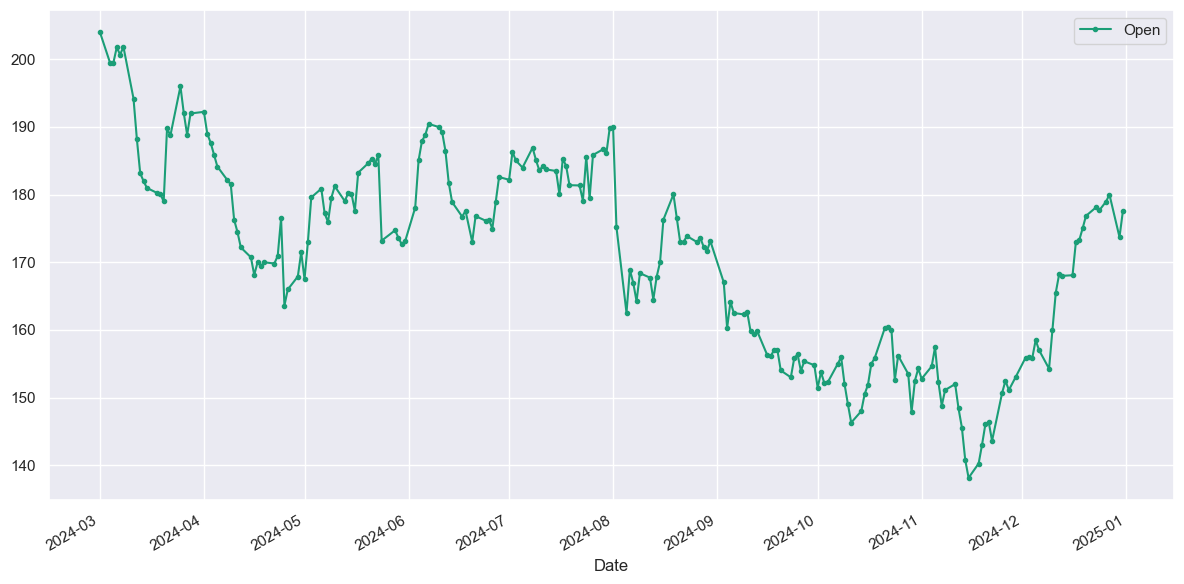

In [600]:
data_b.plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2');
plt.show()

Считаем автокорреляцию при помощи метода pandas - autocorr():

Вначале расчета (на первых шагах) видим высокую корреляцию ~ 1. Значит значения вначале года повторяются, возможно есть сезонность. К средине года корреляция снижается и почти равна 0, т.е. зависимость значений от предыдущих значений снижается. В конце периода корреляция становится отрицательной и последнее значение = -1 - значения чередуются низкое - высокое

In [604]:
for i in range(211):
    print(i+1, data_b['Open'].autocorr(i + 1))

1 0.9685595574304219
2 0.9366663177568271
3 0.907289052747915
4 0.8715973839332901
5 0.8330747500669128
6 0.8021002023342679
7 0.7755570913455712
8 0.7496209139131129
9 0.7375514519215547
10 0.7263147226141322
11 0.7178344649617873
12 0.7091067857897755
13 0.699674414030994
14 0.6907750989076492
15 0.6736691364609941
16 0.656133361638923
17 0.6424166942449613
18 0.6207450807141339
19 0.6020243646132301
20 0.588236000847042
21 0.5727498850166267
22 0.5414953091788889
23 0.5167205689542853
24 0.49854544254379907
25 0.48322077605481867
26 0.47601667013992116
27 0.4694865582783464
28 0.46401082416023653
29 0.46524332768804905
30 0.4711005496554609
31 0.4724943542611675
32 0.47558635600041455
33 0.47451327087902556
34 0.47235270298758186
35 0.4579172539574897
36 0.4448506940238271
37 0.43060755030249154
38 0.41221804387971767
39 0.40214785323521773
40 0.39279123977004987
41 0.38034852522869106
42 0.3655369124978415
43 0.3628642395813863
44 0.3655769002298786
45 0.3607343372956988
46 0.35348

Коррелолаграмма - график автокорреляций для разных лагов

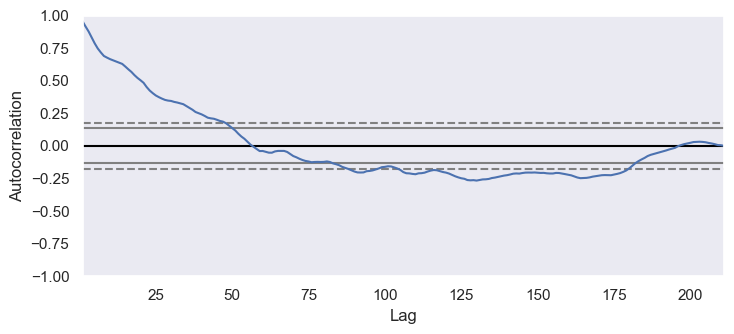

In [607]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(data_b['Open'])
plt.show()

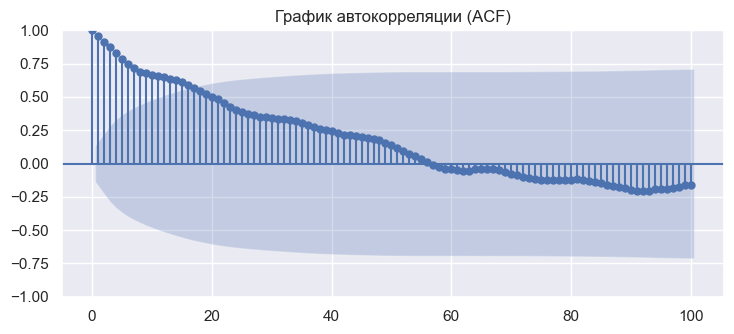

In [609]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data_b['Open'], lags=100)
plt.title('График автокорреляции (ACF)')
plt.show()

Видим, что данные не стационарны и для дальнейшей работы необходима трансофрмация. 
Проведем трансформацию следующими методами: 1)возьмем целевой признак из под квадратного корня 2) log трансофрмацию 3) кокс бокс
Затем сравним полученные результаты с данными до трансформации.


Применим степенную трансформацию данных (возьмем целевой признак из под квадратного корня)

In [612]:
data_b_sgrt = np.sqrt(data_b['Open'])

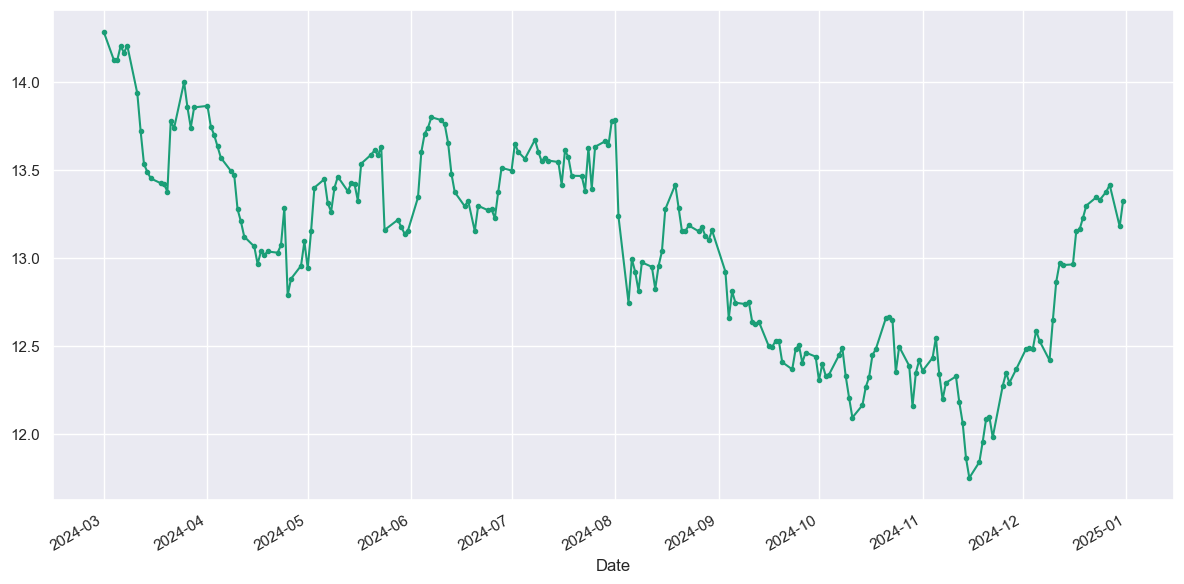

In [614]:
data_b_sgrt.plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2');
plt.show()

Применим log-трансформацию:

In [617]:
data_b_log = np.log(data_b['Open'])

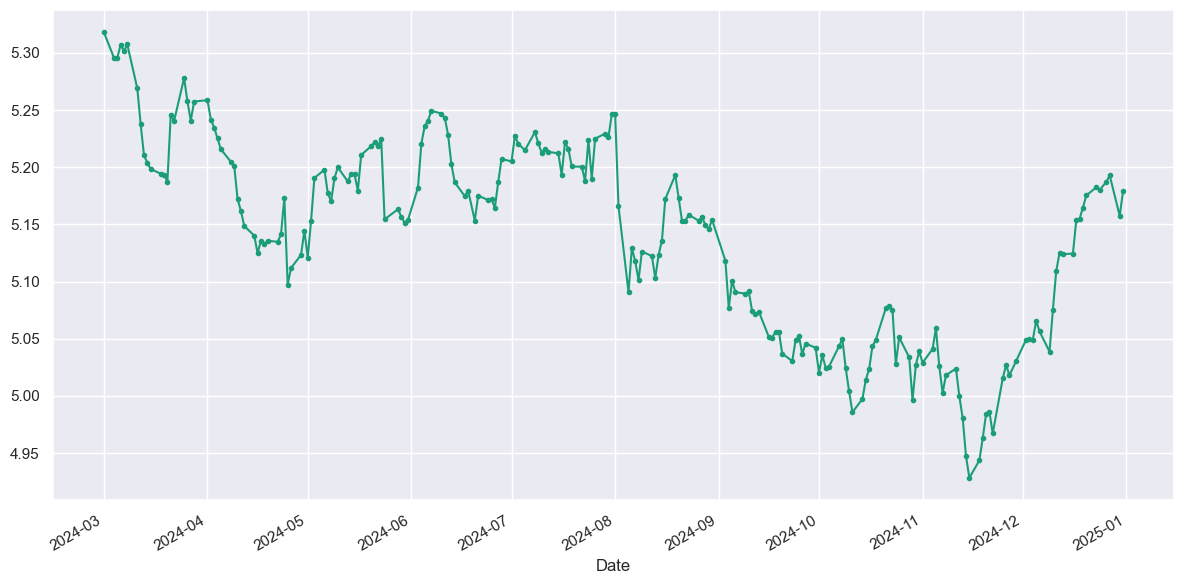

In [619]:
data_b_log.plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2');
plt.show()

Box-Cox трансформация: преобразуем данные в нормальное распределение
Определяем параметр преобразования Бокса Кокса и выполняем преобразование Бокса-Кокса
Параметр включает 1, значит не нужны преобразования. Но выполним для эксперимента

In [622]:
data_bc, lambda_power = scipy.stats.boxcox(data_b['Open'])
print("The lambda is {}".format(round(lambda_power, 2)))

The lambda is 1.65


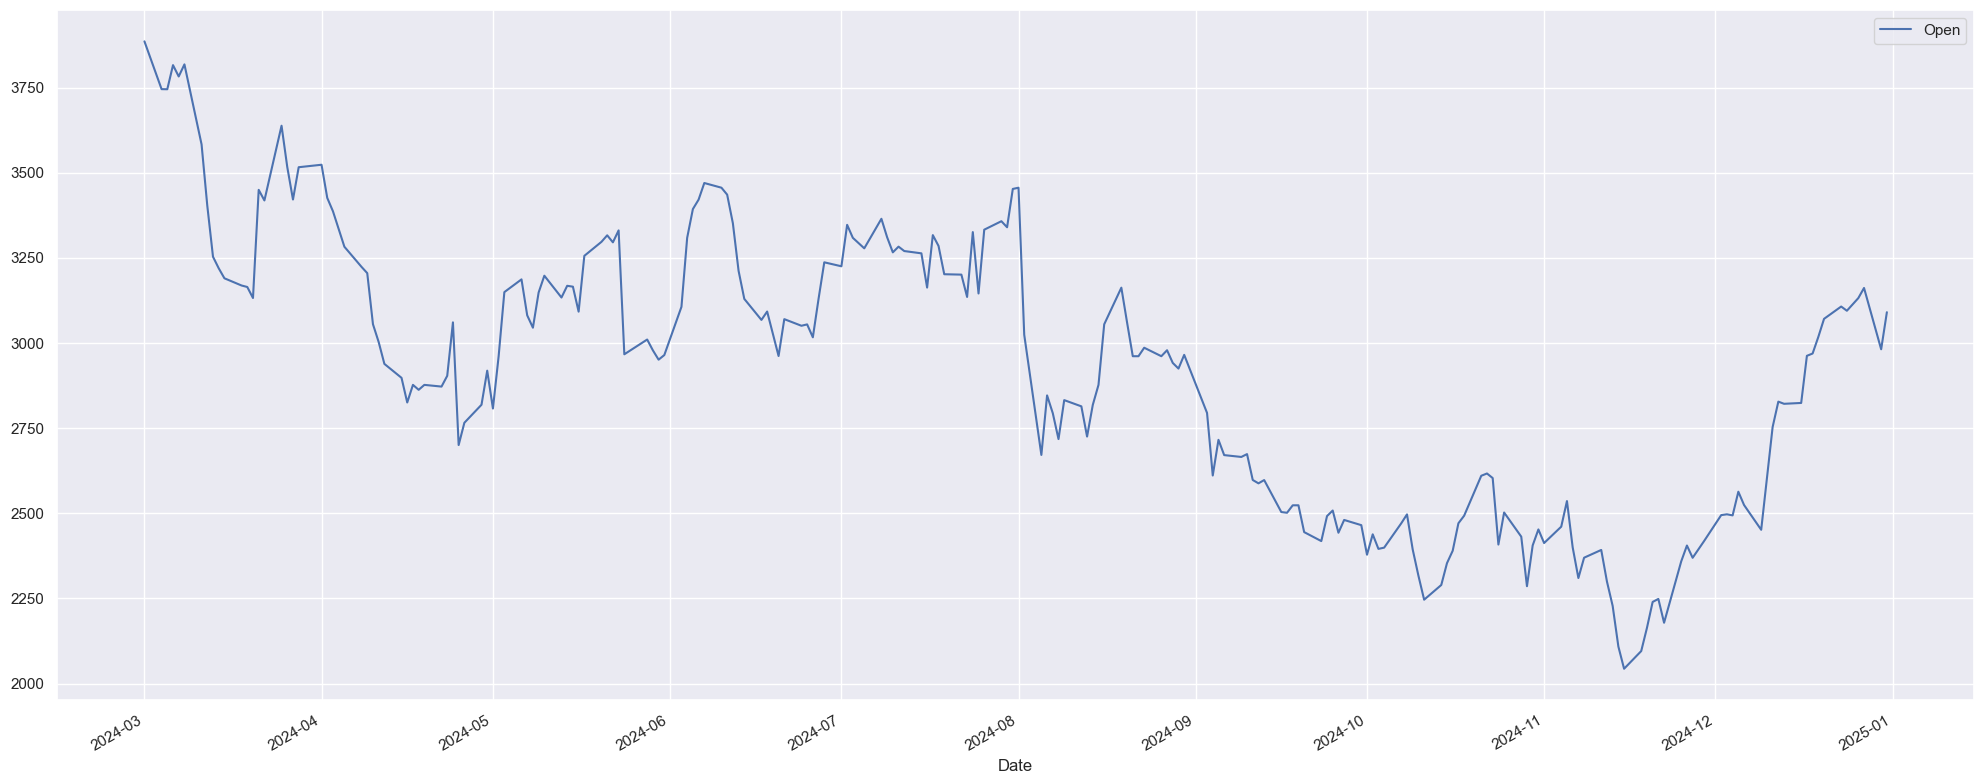

In [624]:
data_b['Open'] = data_bc
#data_b_bc = data_b['Open']
data_b.plot(figsize=(20, 8))
plt.show()

In [ ]:
Визуально графики не изменились, изменилась размерность

Распределение данных после трансформации

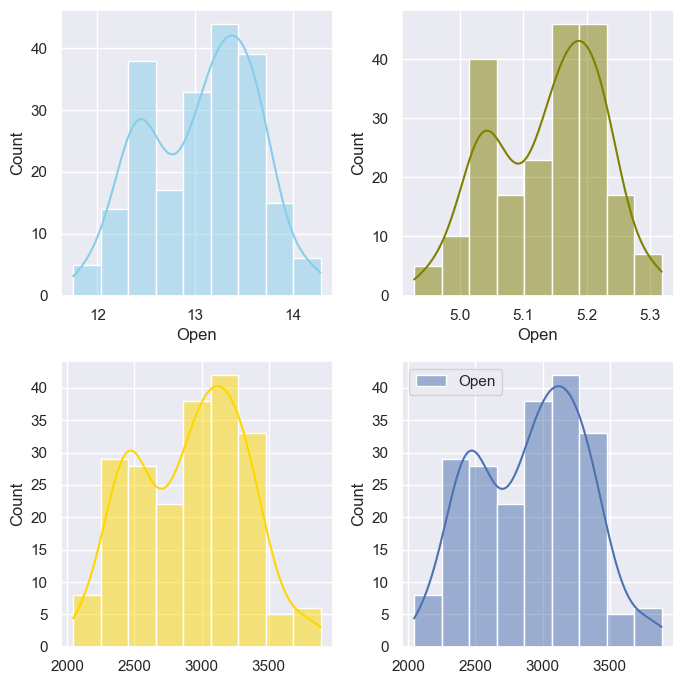

In [627]:
import seaborn as sns
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.set(style="darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

sns.histplot(data=data_b_sgrt,  kde=True, color="skyblue", ax=axs[0, 0])
sns.histplot(data=data_b_log, kde=True, color="olive", ax=axs[0, 1])
sns.histplot(data=data_bc, kde=True, color="gold", ax=axs[1, 0])
sns.histplot(data=data_b, kde=True, color="teal", ax=axs[1, 1])

plt.show()

После выполненных трансформаций видим, графики после трансформации кокса бокса и график до всех трансформаций одинаковые. log трансформация и извлечение корня
Признаки близки к нормальному распределению. 

__APPLE__

In [703]:
a_df = pd.read_csv("D:/DS_2025/9/homework/AAPL.csv")

In [705]:
a_df.head(5)

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,22.04.2025,"198,48","196,15","201,56","196,12","28,77M","2,76%"
1,21.04.2025,"193,16","193,27","193,80","189,81","46,74M","-1,94%"
2,17.04.2025,"196,98","197,20","198,83","194,42","52,16M","1,39%"
3,16.04.2025,"194,27","198,36","200,70","192,37","59,73M","-3,89%"
4,15.04.2025,"202,14","201,85","203,51","199,80","51,34M","-0,19%"


In [707]:
#переименуем столбцы
a_df = a_df.rename(columns= {'Дата':'Date', 'Откр.':'Open', 'Цена':'Close', 'Макс.':'High', 'Мин.': 'Low', 'Объём': 'Volume', 'Изм. %': 'delta'} )

In [709]:
a_df.head(3)

,Date,Close,Open,High,Low,Volume,delta
0,22.04.2025,"198,48","196,15","201,56","196,12","28,77M","2,76%"
1,21.04.2025,"193,16","193,27","193,80","189,81","46,74M","-1,94%"
2,17.04.2025,"196,98","197,20","198,83","194,42","52,16M","1,39%"


In [711]:
a_df.shape

(1066, 7)

In [713]:
#Перевод в datetime object для работы с датой:
a_df['Date'] = pd.to_datetime(a_df['Date'])
a_df['Date'].head(3)

0   2025-04-22
1   2025-04-21
2   2025-04-17
Name: Date, dtype: datetime64[ns]

In [715]:
a_df = a_df.sort_values(['Date'])

In [717]:
a_df

,Date,Close,Open,High,Low,Volume,delta
1065,2021-01-25,"142,92","143,07","145,09","136,54","157,61M","2,77%"
1064,2021-01-26,"143,16","143,60","144,30","141,37","98,39M","0,17%"
1063,2021-01-27,"142,06","143,43","144,30","140,41","140,84M","-0,77%"
1062,2021-01-28,"137,09","139,52","141,99","136,70","142,62M","-3,50%"
1061,2021-01-29,"131,96","135,83","136,74","130,21","177,52M","-3,74%"
...,...,...,...,...,...,...,...
4,2025-04-15,"202,14","201,85","203,51","199,80","51,34M","-0,19%"
3,2025-04-16,"194,27","198,36","200,70","192,37","59,73M","-3,89%"
2,2025-04-17,"196,98","197,20","198,83","194,42","52,16M","1,39%"
1,2025-04-21,"193,16","193,27","193,80","189,81","46,74M","-1,94%"


In [719]:
a_df.set_index('Date', inplace = True)

In [721]:
a_df

,Close,Open,High,Low,Volume,delta
Date,,,,,,
2021-01-25,"142,92","143,07","145,09","136,54","157,61M","2,77%"
2021-01-26,"143,16","143,60","144,30","141,37","98,39M","0,17%"
2021-01-27,"142,06","143,43","144,30","140,41","140,84M","-0,77%"
2021-01-28,"137,09","139,52","141,99","136,70","142,62M","-3,50%"
2021-01-29,"131,96","135,83","136,74","130,21","177,52M","-3,74%"
...,...,...,...,...,...,...
2025-04-15,"202,14","201,85","203,51","199,80","51,34M","-0,19%"
2025-04-16,"194,27","198,36","200,70","192,37","59,73M","-3,89%"
2025-04-17,"196,98","197,20","198,83","194,42","52,16M","1,39%"


Посмотрим на распределение целевого признака:

In [724]:
data_a = a_df.drop(['Close', 'High', 'Low', 'Volume', 'delta'], axis = 1)

In [726]:
data_a = data_a['03.01.2024':'31.12.2024']

In [728]:
data_a['Open'] = data_a['Open'].str.replace(',', '.').astype(float)

In [730]:
data_a.shape

(211, 1)

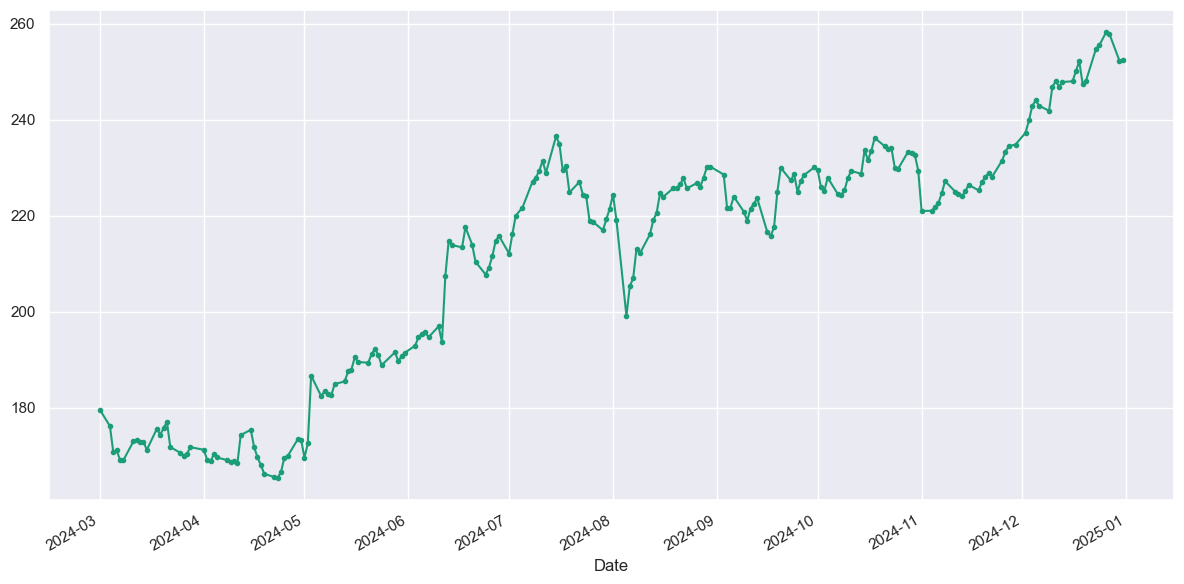

In [732]:
data_a['Open'].plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2')
plt.show()

Считаем автокорреляцию при помощи метода pandas - autocorr():

Вначале расчета (на первых шагах) видим высокую корреляцию ~ 1. Значит значения вначале года повторяются, возможно есть сезонность. К концу года корреляция снижается, т.е. зависимость значений от предыдущих значений снижается. В конце периода корреляция становится отрицательной и последнее значение = -1 - значения чередуются низкое - высокое

In [736]:
for i in range(211):
    print(i+1, data_a['Open'].autocorr(i + 1))

1 0.9916528352206306
2 0.9827860828954595
3 0.9756032465470017
4 0.9694773214341521
5 0.9645178018168535
6 0.958200870223647
7 0.9507233104836034
8 0.9423351666706932
9 0.9346868368713704
10 0.9264936077843801
11 0.9196634038654973
12 0.9122306979072349
13 0.9063161734737637
14 0.8996623483358994
15 0.8934844722635693
16 0.8873398517110903
17 0.8803352823231725
18 0.8741793824489057
19 0.8681501381303867
20 0.8636251375710161
21 0.8584855179501
22 0.8517275677852785
23 0.8455743218692905
24 0.8409531022614422
25 0.8360130710015374
26 0.8310627043993488
27 0.8284497333723465
28 0.8249060860493549
29 0.8208928798302462
30 0.8161107575429798
31 0.8083959729178882
32 0.8012980391516501
33 0.7966774418735562
34 0.7910757020739991
35 0.7851424529075153
36 0.7809735607762883
37 0.7801262900340921
38 0.7784670345503137
39 0.7771686069699744
40 0.7778608764644704
41 0.7780413728878721
42 0.7738689380791499
43 0.7680213434014181
44 0.7613999196835809
45 0.751052513460819
46 0.7413094278757677
47

Коррелолаграмма - график автокорреляций для разных лагов

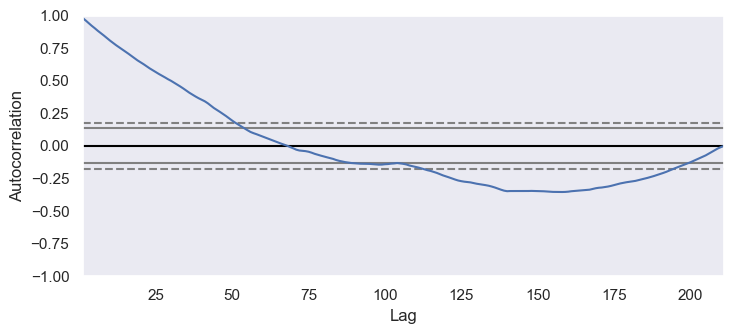

In [739]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(data_a['Open'])
plt.show()

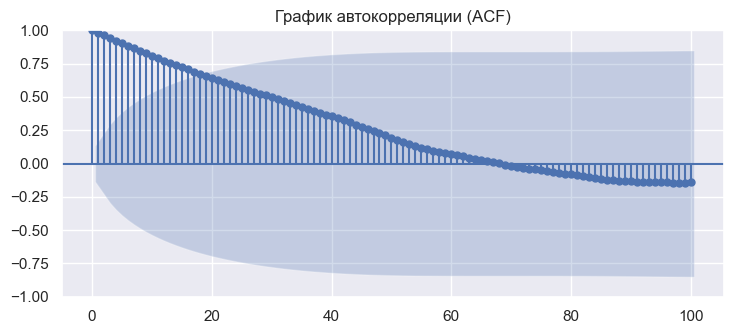

In [741]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data_a['Open'], lags=100)
plt.title('График автокорреляции (ACF)')
plt.show()

Данные не стационарные. Проведем трансформацию. 
1) Применим степенную трансформацию данных (возьмем целевой признак из под квадратного корня): 

In [743]:
data_a_sgrt = np.sqrt(data_a['Open'])

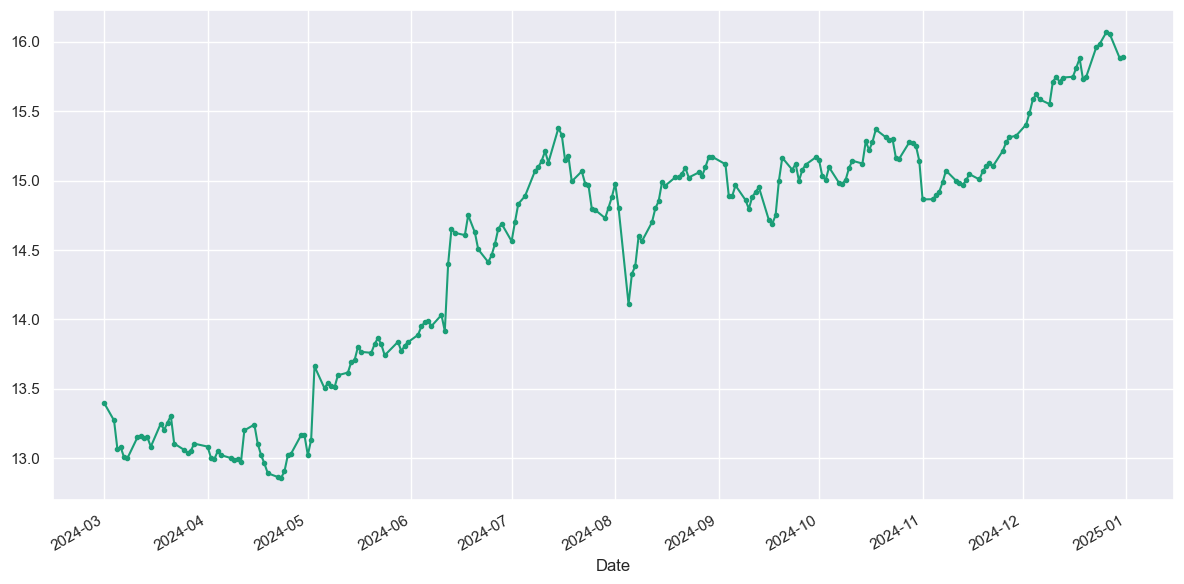

In [745]:
data_a_sgrt.plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2');
plt.show()

2) Применим log-трансформацию

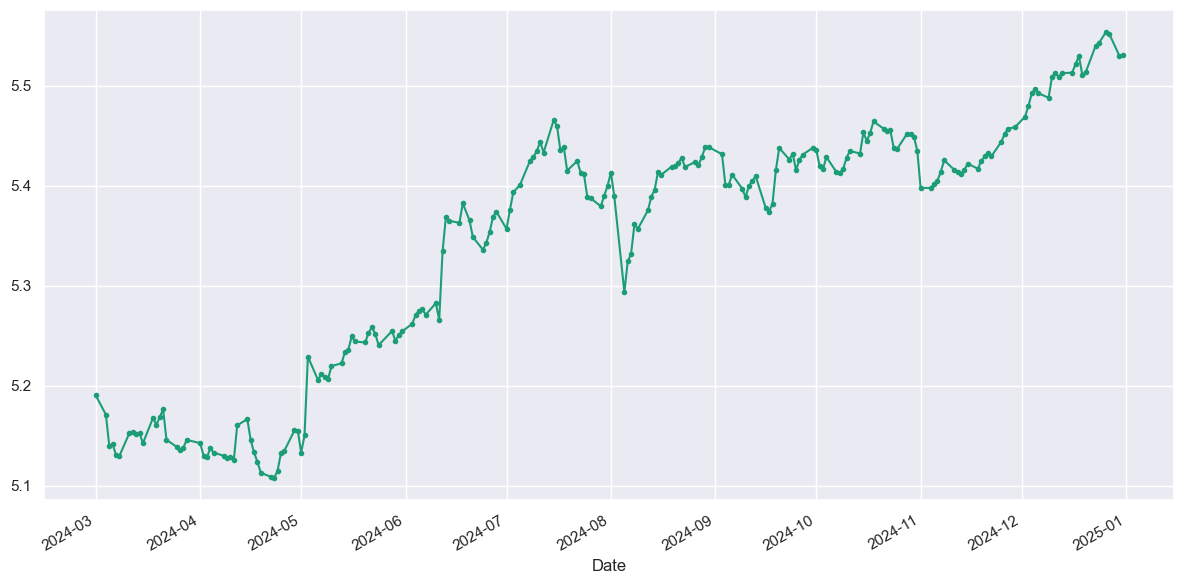

In [747]:
data_a_log = np.log(data_a['Open'])

data_a_log.plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2');
plt.show()

3) Box-Cox трансформация: преобразуем данные в нормальное распределение Определяем параметр преобразования Бокса Кокса и выполняем преобразование Бокса-Кокса Параметр включает 1, значит не нужны преобразования. 
Но выполним для эксперимента


In [749]:
data_bc_a, lambda_power = scipy.stats.boxcox(data_a['Open'])
print("The lambda is {}".format(round(lambda_power, 2)))

The lambda is 2.81


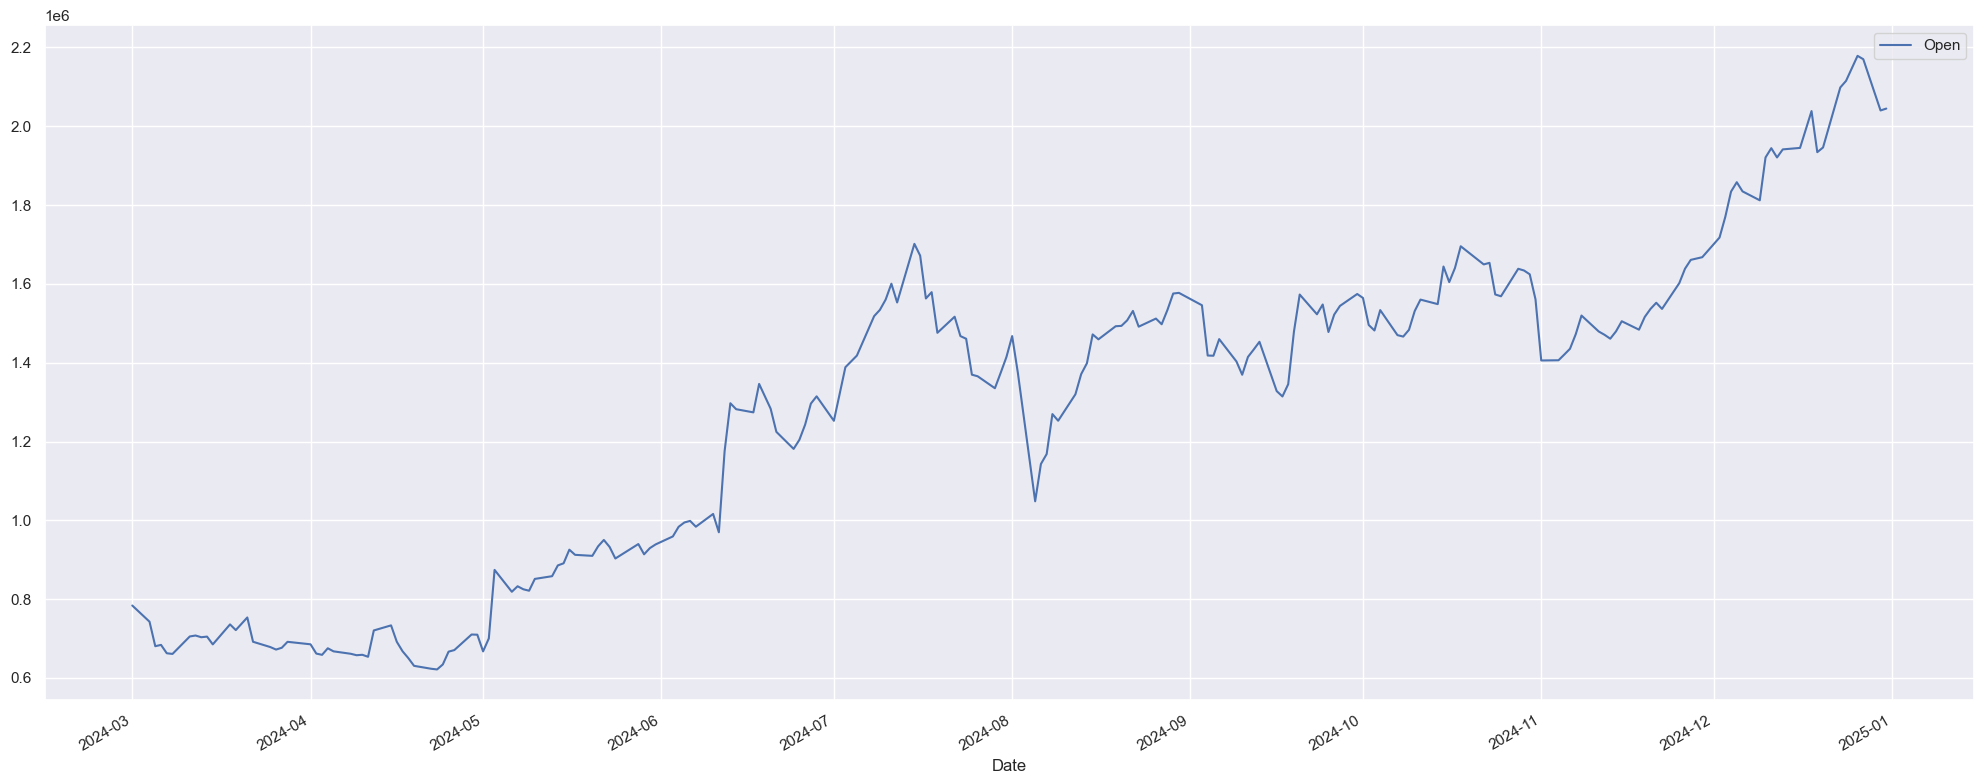

In [753]:
data_a['Open'] = data_bc_a
#data_b_bc = data_b['Open']
data_a.plot(figsize=(20, 8))
plt.show()

Распределение данных после трансформации

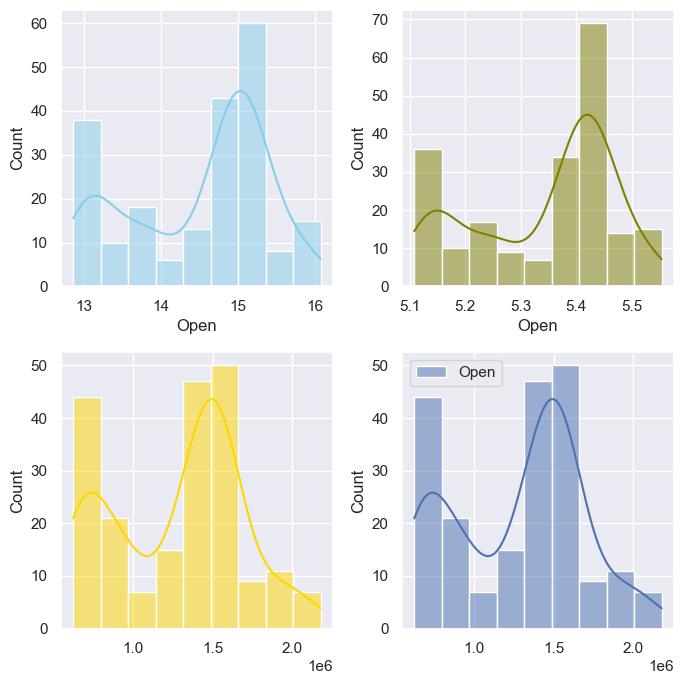

In [755]:
import seaborn as sns
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.set(style="darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

sns.histplot(data=data_a_sgrt,  kde=True, color="skyblue", ax=axs[0, 0])
sns.histplot(data=data_a_log, kde=True, color="olive", ax=axs[0, 1])
sns.histplot(data=data_bc_a, kde=True, color="gold", ax=axs[1, 0])
sns.histplot(data=data_a, kde=True, color="teal", ax=axs[1, 1])

plt.show()


После выполненных трансформаций видим, графики после трансформации кокса бокса и график до всех трансформаций одинаковые. Графики после  логарифмирования и извлечение квадратного корня не различаются

__Объединим датасеты и сравни цену открытия акций Boeing и APPLE__

In [1218]:
b_df = pd.read_csv("D:/DS_2025/9/homework/BA.csv")

In [1220]:
a_df = pd.read_csv("D:/DS_2025/9/homework/AAPL.csv")

In [1222]:
a_df

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,22.04.2025,"198,48","196,15","201,56","196,12","28,77M","2,76%"
1,21.04.2025,"193,16","193,27","193,80","189,81","46,74M","-1,94%"
2,17.04.2025,"196,98","197,20","198,83","194,42","52,16M","1,39%"
3,16.04.2025,"194,27","198,36","200,70","192,37","59,73M","-3,89%"
4,15.04.2025,"202,14","201,85","203,51","199,80","51,34M","-0,19%"
...,...,...,...,...,...,...,...
1061,29.01.2021,"131,96","135,83","136,74","130,21","177,52M","-3,74%"
1062,28.01.2021,"137,09","139,52","141,99","136,70","142,62M","-3,50%"
1063,27.01.2021,"142,06","143,43","144,30","140,41","140,84M","-0,77%"
1064,26.01.2021,"143,16","143,60","144,30","141,37","98,39M","0,17%"


In [1224]:
b_df

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%"
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%"
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%"
3,16.04.2025,"156,47","154,37","157,66","153,54","6,81M","0,61%"
4,15.04.2025,"155,52","155,27","159,12","155,27","11,54M","-2,36%"
...,...,...,...,...,...,...,...
1061,29.01.2021,"194,19","198,30","201,57","193,12","13,68M","-1,54%"
1062,28.01.2021,"197,23","198,04","200,42","196,00","10,40M","1,65%"
1063,27.01.2021,"194,03","196,90","199,47","191,85","20,95M","-3,97%"
1064,26.01.2021,"202,06","205,34","208,35","201,79","11,01M","-0,64%"


In [1226]:
a_df['Name'] = 'APPLE'
b_df['Name'] = 'Boeing'

In [1228]:
a_df.head(3)

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Name
0,22.04.2025,"198,48","196,15","201,56","196,12","28,77M","2,76%",APPLE
1,21.04.2025,"193,16","193,27","193,80","189,81","46,74M","-1,94%",APPLE
2,17.04.2025,"196,98","197,20","198,83","194,42","52,16M","1,39%",APPLE


In [1230]:
b_df.head(3)

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Name
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%",Boeing
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%",Boeing
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%",Boeing


In [1232]:
df = pd.concat([b_df, a_df], axis=0)

In [1234]:
df

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Name
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%",Boeing
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%",Boeing
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%",Boeing
3,16.04.2025,"156,47","154,37","157,66","153,54","6,81M","0,61%",Boeing
4,15.04.2025,"155,52","155,27","159,12","155,27","11,54M","-2,36%",Boeing
...,...,...,...,...,...,...,...,...
1061,29.01.2021,"131,96","135,83","136,74","130,21","177,52M","-3,74%",APPLE
1062,28.01.2021,"137,09","139,52","141,99","136,70","142,62M","-3,50%",APPLE
1063,27.01.2021,"142,06","143,43","144,30","140,41","140,84M","-0,77%",APPLE
1064,26.01.2021,"143,16","143,60","144,30","141,37","98,39M","0,17%",APPLE


In [1236]:
df = df.rename(columns= {'Дата':'Date', 'Откр.':'Open', 'Цена':'Close', 'Макс.':'High', 'Мин.': 'Low', 'Объём': 'Volume', 'Изм. %': 'delta'} )

In [1238]:
df.head(3)

,Date,Close,Open,High,Low,Volume,delta,Name
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%",Boeing
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%",Boeing
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%",Boeing


In [1240]:
#Перевод в datetime object для работы с датой:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head(3)

0   2025-04-22
1   2025-04-21
2   2025-04-17
Name: Date, dtype: datetime64[ns]

In [1242]:
df = df.sort_values(['Date'])

In [1244]:
df

,Date,Close,Open,High,Low,Volume,delta,Name
1065,2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%",Boeing
1065,2021-01-25,"142,92","143,07","145,09","136,54","157,61M","2,77%",APPLE
1064,2021-01-26,"143,16","143,60","144,30","141,37","98,39M","0,17%",APPLE
1064,2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%",Boeing
1063,2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%",Boeing
...,...,...,...,...,...,...,...,...
2,2025-04-17,"196,98","197,20","198,83","194,42","52,16M","1,39%",APPLE
1,2025-04-21,"159,34","162,40","160,00","156,47","5,70M","-1,58%",Boeing
1,2025-04-21,"193,16","193,27","193,80","189,81","46,74M","-1,94%",APPLE
0,2025-04-22,"198,48","196,15","201,56","196,12","28,77M","2,76%",APPLE


In [1246]:
df.set_index('Date', inplace = True)

In [1248]:
df

,Close,Open,High,Low,Volume,delta,Name
Date,,,,,,,
2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%",Boeing
2021-01-25,"142,92","143,07","145,09","136,54","157,61M","2,77%",APPLE
2021-01-26,"143,16","143,60","144,30","141,37","98,39M","0,17%",APPLE
2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%",Boeing
2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%",Boeing
...,...,...,...,...,...,...,...
2025-04-17,"196,98","197,20","198,83","194,42","52,16M","1,39%",APPLE
2025-04-21,"159,34","162,40","160,00","156,47","5,70M","-1,58%",Boeing
2025-04-21,"193,16","193,27","193,80","189,81","46,74M","-1,94%",APPLE


In [1250]:
df = df.drop(['Open', 'High', 'Low', 'Volume', 'delta'], axis = 1)

In [1252]:
df.head(3)

,Close,Name
Date,,
2021-01-25,"203,36",Boeing
2021-01-25,"142,92",APPLE
2021-01-26,"143,16",APPLE


In [1254]:
df = df['03.01.2023':'31.12.2024']


In [1256]:
df['Close'] = df['Close'].str.replace(',', '.').astype(float)

In [1258]:
df.dtypes

Close    float64
Name      object
dtype: object

In [1260]:
close_price = pd.pivot_table(df, values='Close', index=['Date'],
                       columns=['Name'], aggfunc="sum")

In [1262]:
close_price

Name,APPLE,Boeing
Date,,
2023-03-01,145.31,204.55
2023-03-02,145.91,210.06
2023-03-03,151.03,215.11
2023-03-06,153.83,211.92
2023-03-07,151.60,207.92
...,...,...
2024-12-24,258.20,179.34
2024-12-26,259.02,180.38
2024-12-27,255.59,180.72


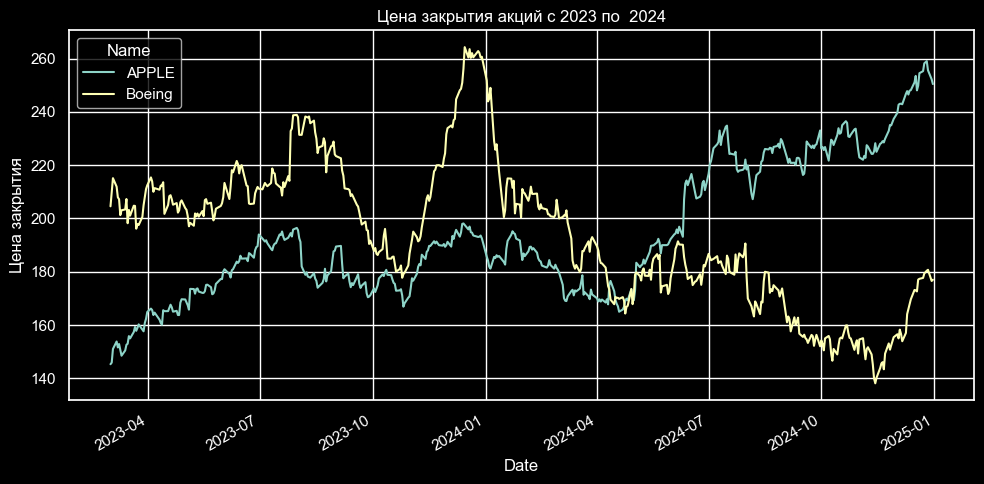

In [1264]:
start_dt = '2023'
end_dt = ' 2024'
plt.style.use("dark_background")
plot = close_price.plot(
    title=f'Цена закрытия акций с {start_dt} по {end_dt}',
    ylabel="Цена закрытия", figsize=(10, 5))

plt.show()

Необходимо провести нормирование данных при помощи деления на исходное значение
Чтобы приблизить данные к нормальным

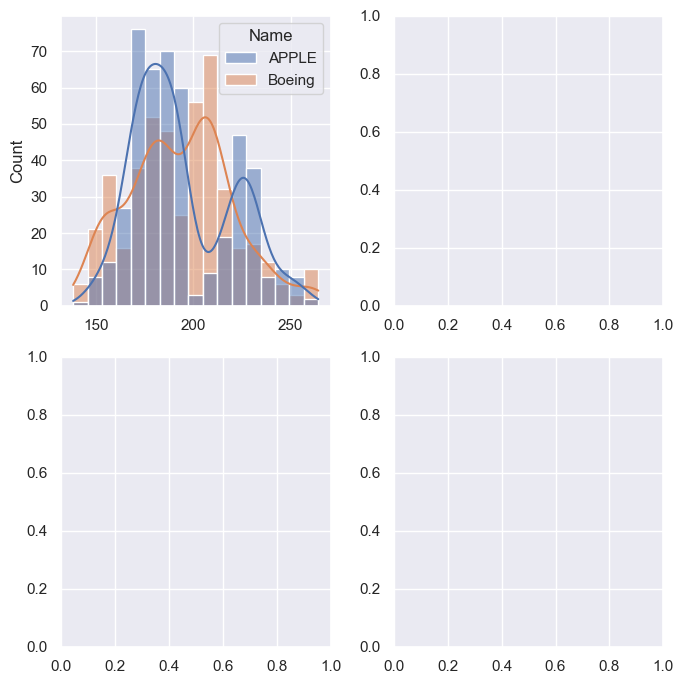

In [1267]:
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.set(style="darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

sns.histplot(data=close_price,  kde=True, color="skyblue", ax=axs[0, 0])

plt.show()

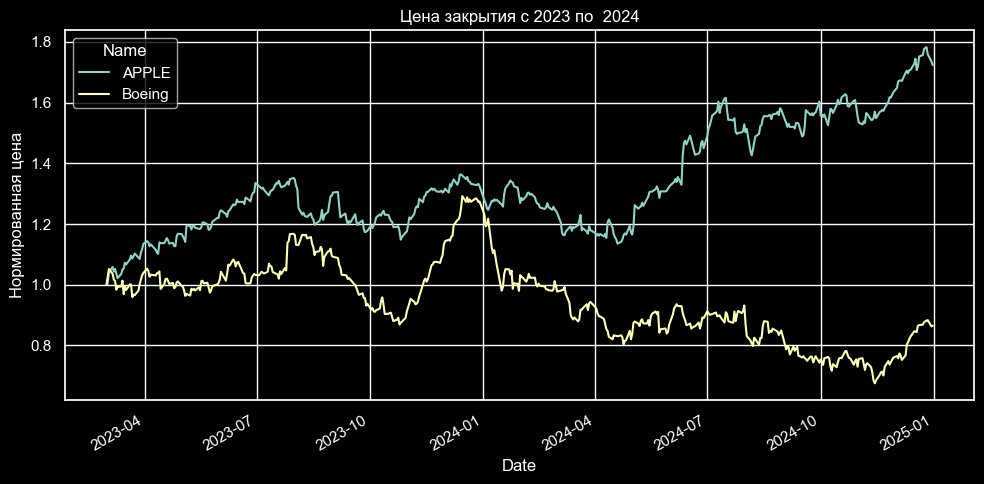

In [1270]:
close_price = close_price.div(close_price.iloc[0])
plt.style.use("dark_background")
plot = close_price.plot(
            title=f'Цена закрытия с {start_dt} по {end_dt}',
            ylabel= 'Нормированная цена', figsize=(10, 5))
plt.show()

После выполненных преобразований графики 'растянулись' вдоль оси

На гистограмме видим, что данные нормализованы. Изображение в форме купола, не рассредоточены вдоль оси Х

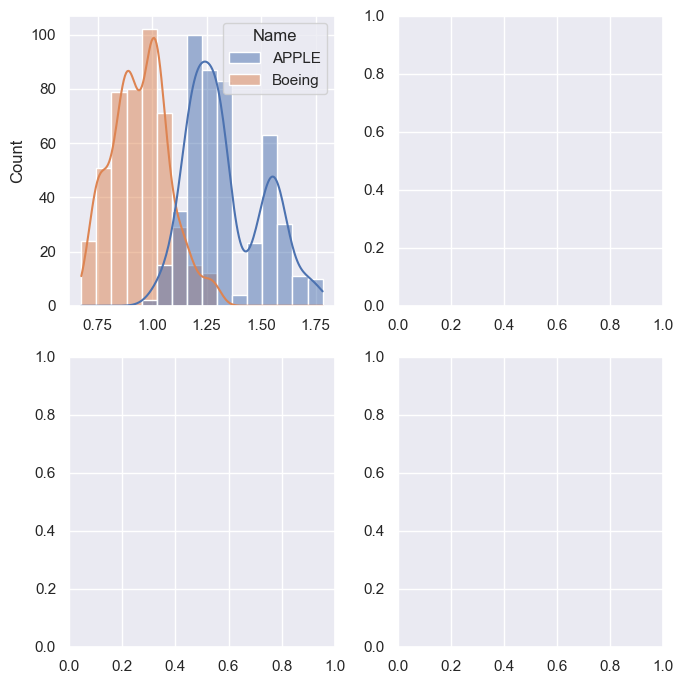

In [1274]:
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
sns.set(style="darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

sns.histplot(data=close_price,  kde=True, color="skyblue", ax=axs[0, 0])

plt.show()

Выполним декомпозицию временного ряда — разделить временной ряд на его основные составляющие, чтобы понять структуру данных

In [1277]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.seasonal import seasonal_decompose

In [1279]:
df_Boeing = df[df['Name'] == 'Boeing']

In [1281]:
df_APPLE = df[df['Name'] == 'APPLE']

Results of Dickey-Fuller Test:
Test Statistic                  -1.518109
p-value                          0.524535
#Lags Used                       0.000000
Number of Observations Used    462.000000
Critical Value (1%)             -3.444584
Critical Value (5%)             -2.867816
Critical Value (10%)            -2.570113
dtype: float64


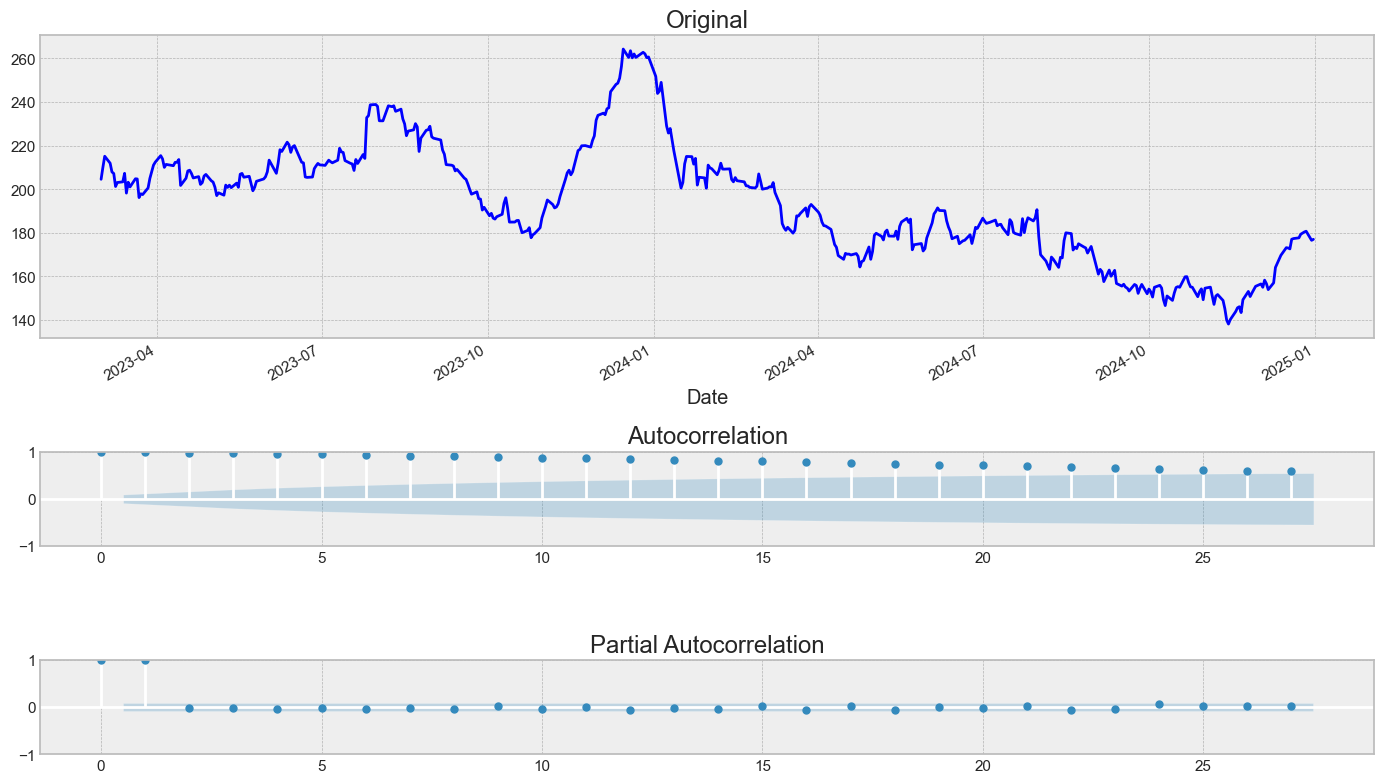

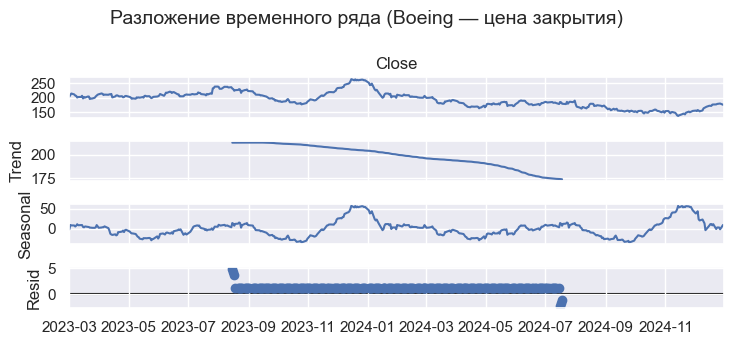

In [1283]:
# Тест на стационарность (ADF)
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()
    return

tsplot(df_Boeing['Close'])

decomposition = seasonal_decompose(df_Boeing['Close'], model='additive', period=230)
decomposition.plot()
plt.suptitle("Разложение временного ряда (Boeing — цена закрытия)", fontsize=14)
plt.tight_layout()
plt.show()

p-value необходимо продиффиринцировать:

In [1319]:
df_Boeing_diff = df_Boeing['Close'].diff().dropna()

Results of Dickey-Fuller Test:
Test Statistic                 -21.445288
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    461.000000
Critical Value (1%)             -3.444615
Critical Value (5%)             -2.867830
Critical Value (10%)            -2.570120
dtype: float64


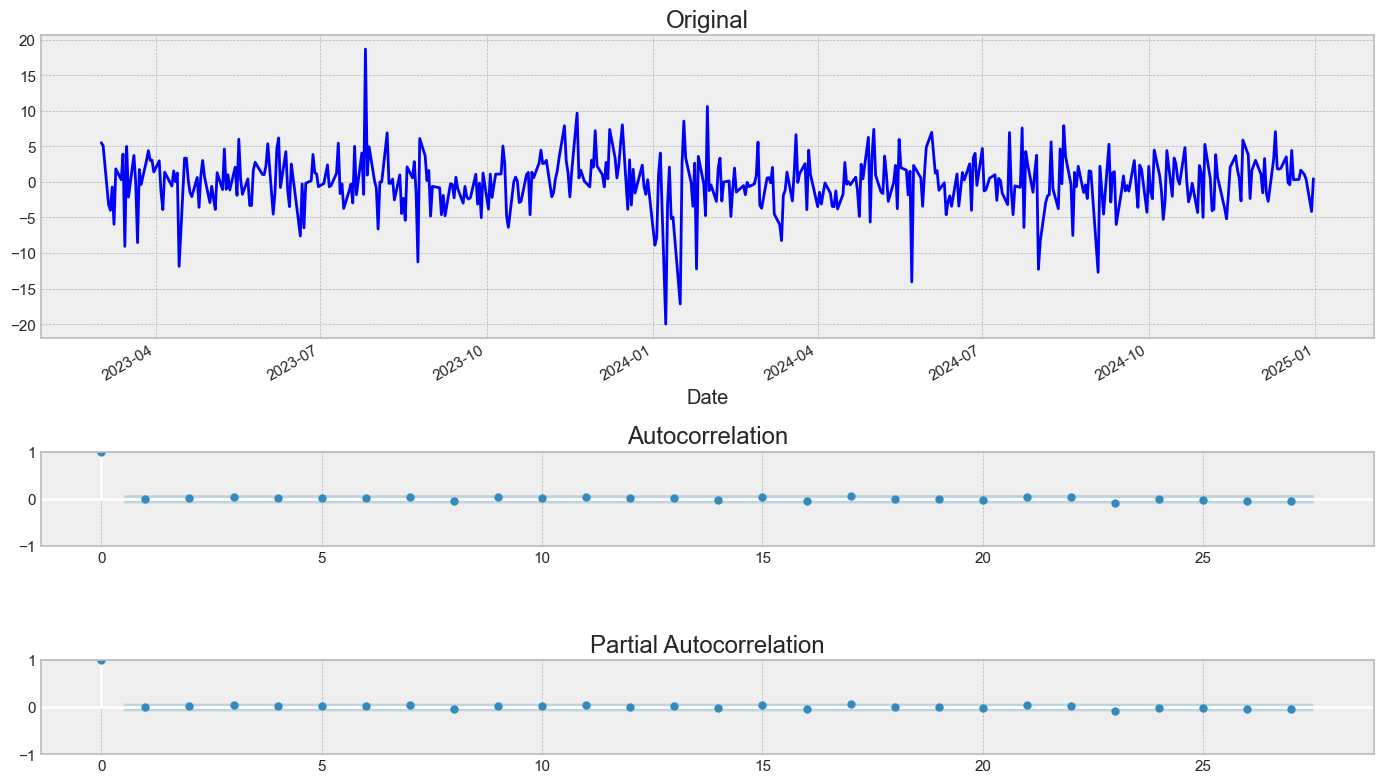

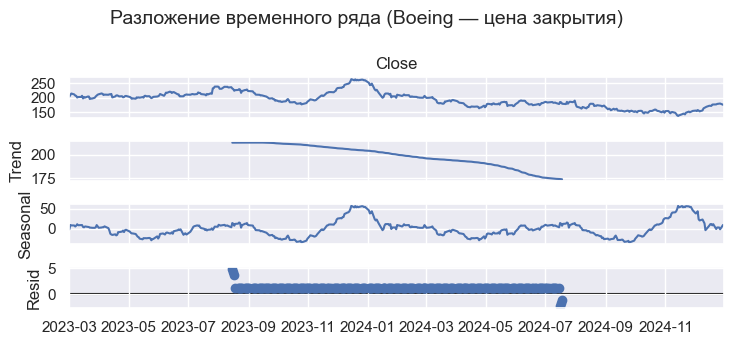

In [1323]:
tsplot(df_Boeing_diff)

decomposition = seasonal_decompose(df_Boeing['Close'], model='additive', period=230)
decomposition.plot()
plt.suptitle("Разложение временного ряда (Boeing — цена закрытия)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
После дифф-я p-value -  0.000000. Ряд стационарный, данные распределны вокруг ноля - Boeing 

Results of Dickey-Fuller Test:
Test Statistic                  -0.900560
p-value                          0.787788
#Lags Used                       1.000000
Number of Observations Used    461.000000
Critical Value (1%)             -3.444615
Critical Value (5%)             -2.867830
Critical Value (10%)            -2.570120
dtype: float64


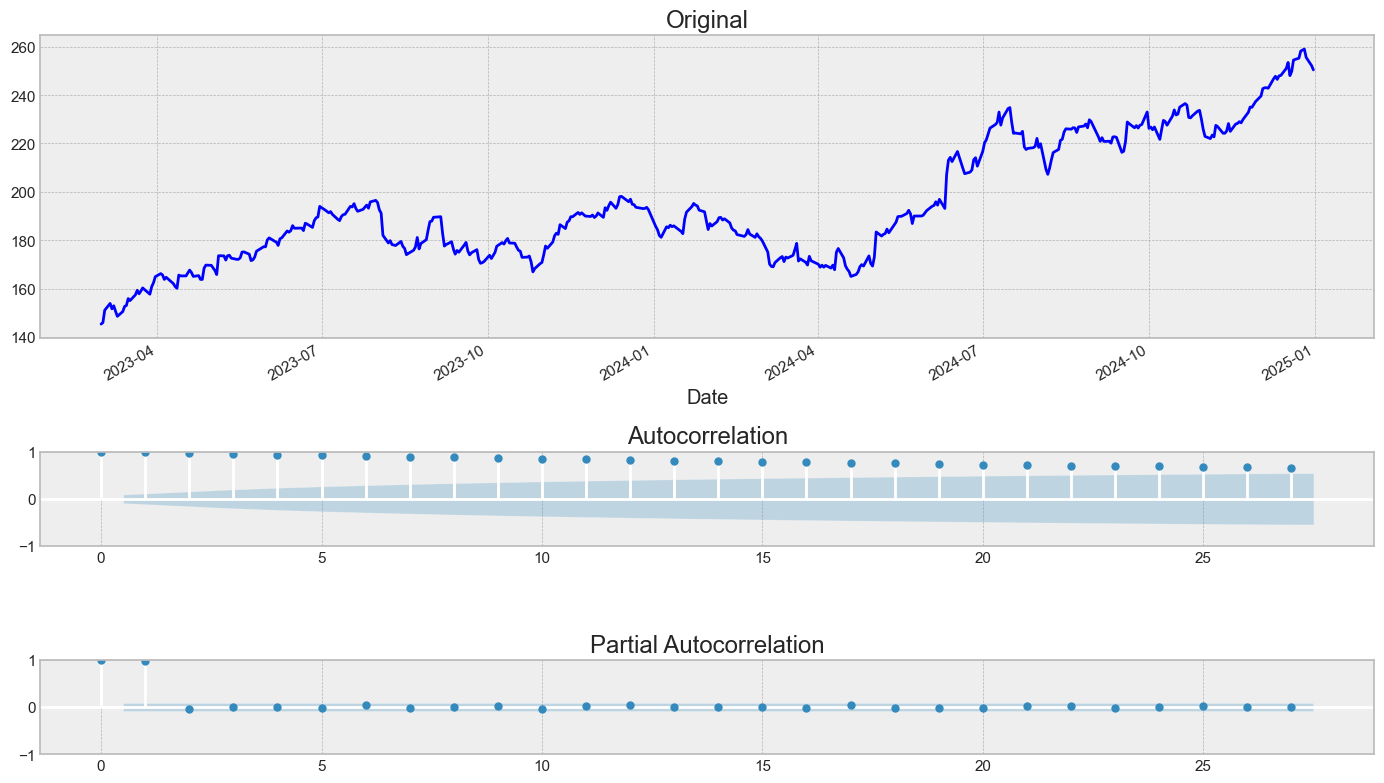

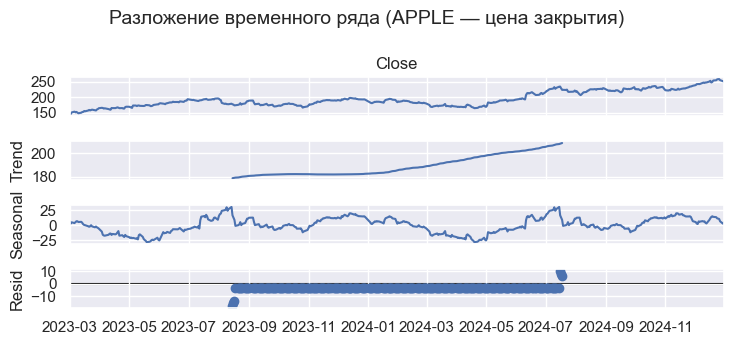

In [1290]:
tsplot(df_APPLE['Close'])

decomposition = seasonal_decompose(df_APPLE['Close'], model='additive', period=230)
decomposition.plot()
plt.suptitle("Разложение временного ряда (APPLE — цена закрытия)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
p-value необходимо продиффиринцировать:

In [1325]:
df_APPLE_diff = df_APPLE['Close'].diff().dropna()

Results of Dickey-Fuller Test:
Test Statistic                 -19.915687
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    461.000000
Critical Value (1%)             -3.444615
Critical Value (5%)             -2.867830
Critical Value (10%)            -2.570120
dtype: float64


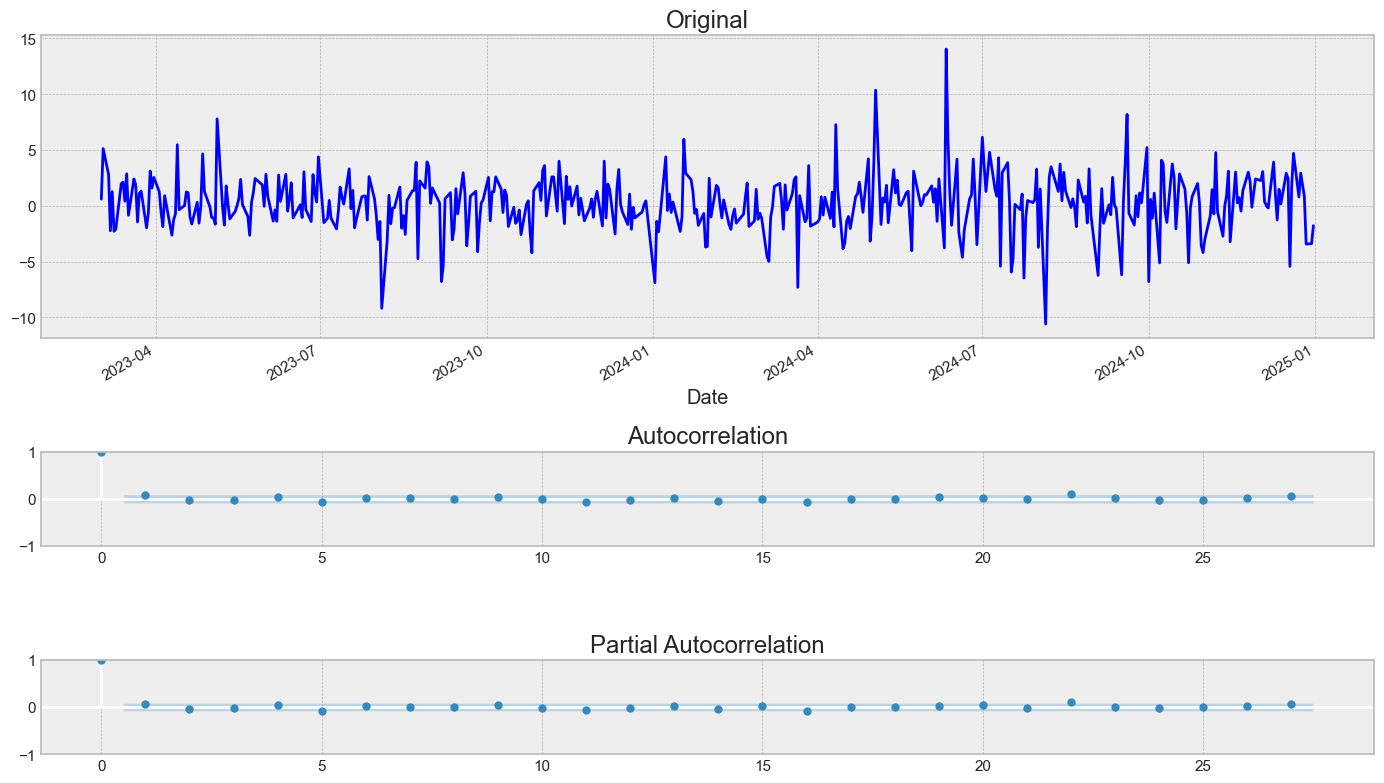

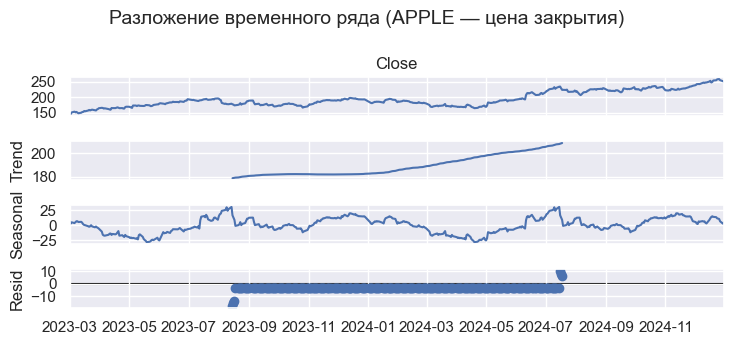

In [1327]:
tsplot(df_APPLE_diff)

decomposition = seasonal_decompose(df_APPLE['Close'], model='additive', period=230)
decomposition.plot()
plt.suptitle("Разложение временного ряда (APPLE — цена закрытия)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
После дифф-я p-value -  0.000000. Ряд стационарный, данные распределны вокруг ноля - APPLE

Исследование проводилось для акций Boeing и APPLE. Проанализировано распределение признаков по каждой компании с применением различных методов для нормализации данных.
Также проведено сравнение временных для компаний Boeing и APPLE (наложение временных рядов на один график)
Выполнено разложение временных рядов (тренл, сезонность, остатки).
Выполнена проверка на стационарность временных рядов. ВР не стационарны. После проведения дифференцирования ВР прошли тест на стационарность (p-value -  0.000000, график корреляции - нет разброса).
Данные готовы для прогнозирования